# A/B Testing: Advertising Campaign vs. Public Service Announcement

Does showing users an advertisement instead of a public service announcement (PSA) change
how likely they are to convert? This notebook tests that on 588,101 real users with a
chi-squared test, then works through the standard pitfall checks (sample ratio mismatch,
Simpson's paradox across subgroups, and chi-squared's own validity assumption) before
treating the headline result as trustworthy.

**Data**: Marketing A/B Testing dataset (Kaggle), `marketing_AB.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, chisquare
from statsmodels.stats.proportion import proportion_confint

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## Data overview

Two groups: users shown ads (treatment) and users shown a PSA (control). The outcome is
binary: whether the user converted.

In [2]:
df = pd.read_csv('marketing_AB.csv')

print(f"rows: {len(df):,}   columns: {len(df.columns)}")
print()
print(df['test group'].value_counts())
print()
print(df['converted'].value_counts())

rows: 588,101   columns: 7

test group
ad     564577
psa     23524
Name: count, dtype: int64

converted
False    573258
True      14843
Name: count, dtype: int64


## Conversion rate by group

The two groups are far from evenly sized (roughly 96:4, ad vs. PSA), which is addressed
directly in the sample ratio mismatch check further down.

In [3]:
ad_group = df[df['test group'] == 'ad']
psa_group = df[df['test group'] == 'psa']

ad_conversion_rate = ad_group['converted'].mean()
psa_conversion_rate = psa_group['converted'].mean()

absolute_lift = ad_conversion_rate - psa_conversion_rate
relative_lift = absolute_lift / psa_conversion_rate * 100

print(f"PSA (control):   n={len(psa_group):>8,}   conversion={psa_conversion_rate*100:.2f}%")
print(f"Ad (treatment):  n={len(ad_group):>8,}   conversion={ad_conversion_rate*100:.2f}%")
print()
print(f"Absolute lift:  {absolute_lift*100:.2f} percentage points")
print(f"Relative lift:  {relative_lift:.2f}%")

PSA (control):   n=  23,524   conversion=1.79%
Ad (treatment):  n= 564,577   conversion=2.55%

Absolute lift:  0.77 percentage points
Relative lift:  43.09%


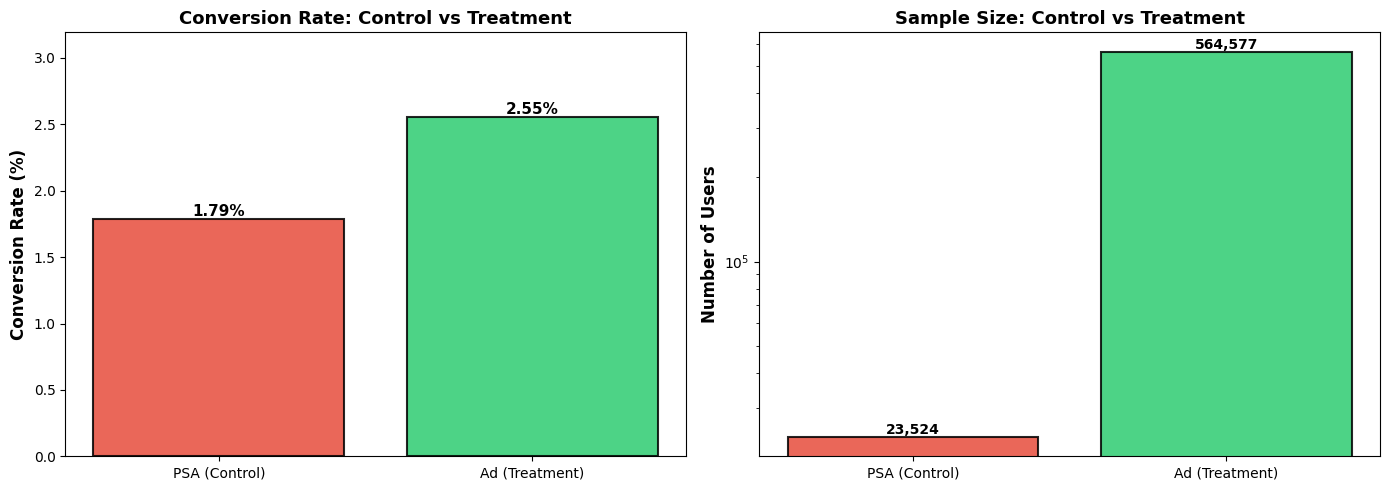

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

groups = ['PSA (Control)', 'Ad (Treatment)']
conversion_rates = [psa_conversion_rate * 100, ad_conversion_rate * 100]
colors = ['#e74c3c', '#2ecc71']

ax1 = axes[0]
bars = ax1.bar(groups, conversion_rates, color=colors, alpha=0.85, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Conversion Rate: Control vs Treatment', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(conversion_rates) * 1.25)
for bar, rate in zip(bars, conversion_rates):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{rate:.2f}%',
              ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2 = axes[1]
sample_sizes = [len(psa_group), len(ad_group)]
bars2 = ax2.bar(groups, sample_sizes, color=colors, alpha=0.85, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
ax2.set_title('Sample Size: Control vs Treatment', fontsize=13, fontweight='bold')
ax2.set_yscale('log')
for bar, size in zip(bars2, sample_sizes):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{size:,}',
              ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('conversion_rate_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Hypothesis test

- **H0**: ad conversion rate = PSA conversion rate
- **H1**: ad conversion rate &ne; PSA conversion rate
- **Test**: chi-squared test of independence on the 2&times;2 contingency table (group &times; converted), appropriate since the outcome is binary
- **Significance level**: &alpha; = 0.05

In [5]:
contingency_table = pd.crosstab(df['test group'], df['converted'])
print(contingency_table)

chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)

print()
print(f"chi-squared: {chi2:.4f}   p-value: {p_value:.2e}   dof: {dof}")
print(f"Result: {'reject H0 (significant)' if p_value < 0.05 else 'fail to reject H0'} at alpha=0.05")
print(f"Observed relative lift: {relative_lift:.2f}%")

converted    False  True 
test group               
ad          550154  14423
psa          23104    420

chi-squared: 54.0058   p-value: 2.00e-13   dof: 1
Result: reject H0 (significant) at alpha=0.05
Observed relative lift: 43.09%


## Checking for pitfalls before trusting the result

A significant p-value on its own isn't sufficient. Three checks below: whether the group
sizes match the intended assignment (sample ratio mismatch), whether the effect reverses
in any subgroup (Simpson's paradox), and whether chi-squared's own sample-size assumption
holds.

In [6]:
# Sample ratio mismatch (SRM)
observed = [len(ad_group), len(psa_group)]
expected_5050 = [len(df) / 2, len(df) / 2]
chi2_srm, p_srm = chisquare(observed, expected_5050)

print(f"Observed split -> ad: {len(ad_group):,} ({len(ad_group)/len(df)*100:.1f}%)   "
      f"psa: {len(psa_group):,} ({len(psa_group)/len(df)*100:.1f}%)")
print(f"Chi-squared against a 50:50 null: chi2={chi2_srm:.2f}, p={p_srm:.2e}")
print()
print("Note: the true intended allocation ratio for this experiment isn't known, so testing")
print("against a 50:50 null doesn't actually confirm or rule out an assignment problem here;")
print("the 96:4 split is plausible as an intentional design choice, but that's an assumption,")
print("not something this check verifies.")

Observed split -> ad: 564,577 (96.0%)   psa: 23,524 (4.0%)
Chi-squared against a 50:50 null: chi2=497768.83, p=0.00e+00

Note: the true intended allocation ratio for this experiment isn't known, so testing
against a 50:50 null doesn't actually confirm or rule out an assignment problem here;
the 96:4 split is plausible as an intentional design choice, but that's an assumption,
not something this check verifies.


In [7]:
# Simpson's paradox: does the direction of the effect reverse in any subgroup?
print("Lift by day of week:")
lifts_by_day = {}
for day in df['most ads day'].unique():
    day_df = df[df['most ads day'] == day]
    ad_day = day_df[day_df['test group'] == 'ad']
    psa_day = day_df[day_df['test group'] == 'psa']
    if len(ad_day) and len(psa_day):
        ad_conv = ad_day['converted'].mean() * 100
        psa_conv = psa_day['converted'].mean() * 100
        lift = (ad_conv - psa_conv) / psa_conv * 100
        lifts_by_day[day] = lift
        print(f"  {day:10s}  ad={ad_conv:5.2f}%  psa={psa_conv:5.2f}%  lift={lift:+6.1f}%")

df['time_of_day'] = pd.cut(df['most ads hour'], bins=[0, 11, 17, 24],
                            labels=['Morning (0-11)', 'Afternoon (12-17)', 'Evening (18-23)'])
excluded_hour0 = (df['most ads hour'] == 0).sum()

print()
print("Lift by time of day:")
lifts_by_time = {}
for period in df['time_of_day'].cat.categories:
    period_df = df[df['time_of_day'] == period]
    ad_p = period_df[period_df['test group'] == 'ad']
    psa_p = period_df[period_df['test group'] == 'psa']
    if len(ad_p) and len(psa_p):
        ad_conv = ad_p['converted'].mean() * 100
        psa_conv = psa_p['converted'].mean() * 100
        lift = (ad_conv - psa_conv) / psa_conv * 100
        lifts_by_time[period] = lift
        print(f"  {str(period):20s}  ad={ad_conv:5.2f}%  psa={psa_conv:5.2f}%  lift={lift:+6.1f}%")

print()
print(f"Note: {excluded_hour0:,} users with hour==0 fall outside all three bins above")
print("(pd.cut's default interval edges exclude the lower bound) and are not represented")
print("in the time-of-day breakdown, though they are included in every other calculation.")
print()
no_reversal = all(v > 0 for v in list(lifts_by_day.values()) + list(lifts_by_time.values()))
print(f"Lift stayed positive in every subgroup checked: {no_reversal}")
print("(consistent direction across subgroups is what rules out Simpson's paradox here;")
print(" it does not rule out an interaction that wasn't checked, e.g. day x hour jointly)")

Lift by day of week:
  Monday      ad= 3.32%  psa= 2.26%  lift= +47.4%
  Tuesday     ad= 3.04%  psa= 1.44%  lift=+110.7%
  Friday      ad= 2.25%  psa= 1.63%  lift= +37.8%
  Saturday    ad= 2.13%  psa= 1.40%  lift= +52.2%


  Wednesday   ad= 2.54%  psa= 1.58%  lift= +60.9%
  Sunday      ad= 2.46%  psa= 2.06%  lift= +19.5%
  Thursday    ad= 2.16%  psa= 2.02%  lift=  +7.0%

Lift by time of day:
  Morning (0-11)        ad= 2.03%  psa= 1.17%  lift= +73.0%
  Afternoon (12-17)     ad= 2.77%  psa= 2.02%  lift= +37.3%
  Evening (18-23)       ad= 2.74%  psa= 2.07%  lift= +32.8%

Note: 5,536 users with hour==0 fall outside all three bins above
(pd.cut's default interval edges exclude the lower bound) and are not represented
in the time-of-day breakdown, though they are included in every other calculation.

Lift stayed positive in every subgroup checked: True
(consistent direction across subgroups is what rules out Simpson's paradox here;
 it does not rule out an interaction that wasn't checked, e.g. day x hour jointly)


In [8]:
# Chi-squared validity assumption
print("Expected frequencies:")
print(expected_freq)
print()
print(f"All expected frequencies >= 5: {(expected_freq >= 5).all()}")

Expected frequencies:
[[550327.71899045  14249.28100955]
 [ 22930.28100955    593.71899045]]

All expected frequencies >= 5: True


## Confidence intervals and business impact

In [9]:
ad_conversions = ad_group['converted'].sum()
psa_conversions = psa_group['converted'].sum()

ad_ci = proportion_confint(ad_conversions, len(ad_group), alpha=0.05, method='wilson')
psa_ci = proportion_confint(psa_conversions, len(psa_group), alpha=0.05, method='wilson')

print(f"95% CI, ad:  {ad_ci[0]*100:.2f}% - {ad_ci[1]*100:.2f}%")
print(f"95% CI, psa: {psa_ci[0]*100:.2f}% - {psa_ci[1]*100:.2f}%")
print(f"Intervals overlap: {not (ad_ci[0] > psa_ci[1] or psa_ci[0] > ad_ci[1])}")

95% CI, ad:  2.51% - 2.60%
95% CI, psa: 1.62% - 1.96%
Intervals overlap: False


In [10]:
print("Projected additional conversions if ads replaced PSAs, at scale:")
for users in [100_000, 1_000_000, 10_000_000]:
    additional = int(absolute_lift * users)
    print(f"  {users:>10,} users: +{additional:,} conversions")

revenue_per_1m = int(absolute_lift * 1_000_000 * 100)
print(f"\nAt $100 per conversion, 1M users: +${revenue_per_1m:,} revenue")

Projected additional conversions if ads replaced PSAs, at scale:
     100,000 users: +769 conversions
   1,000,000 users: +7,692 conversions
  10,000,000 users: +76,924 conversions

At $100 per conversion, 1M users: +$769,245 revenue


## Visual summary

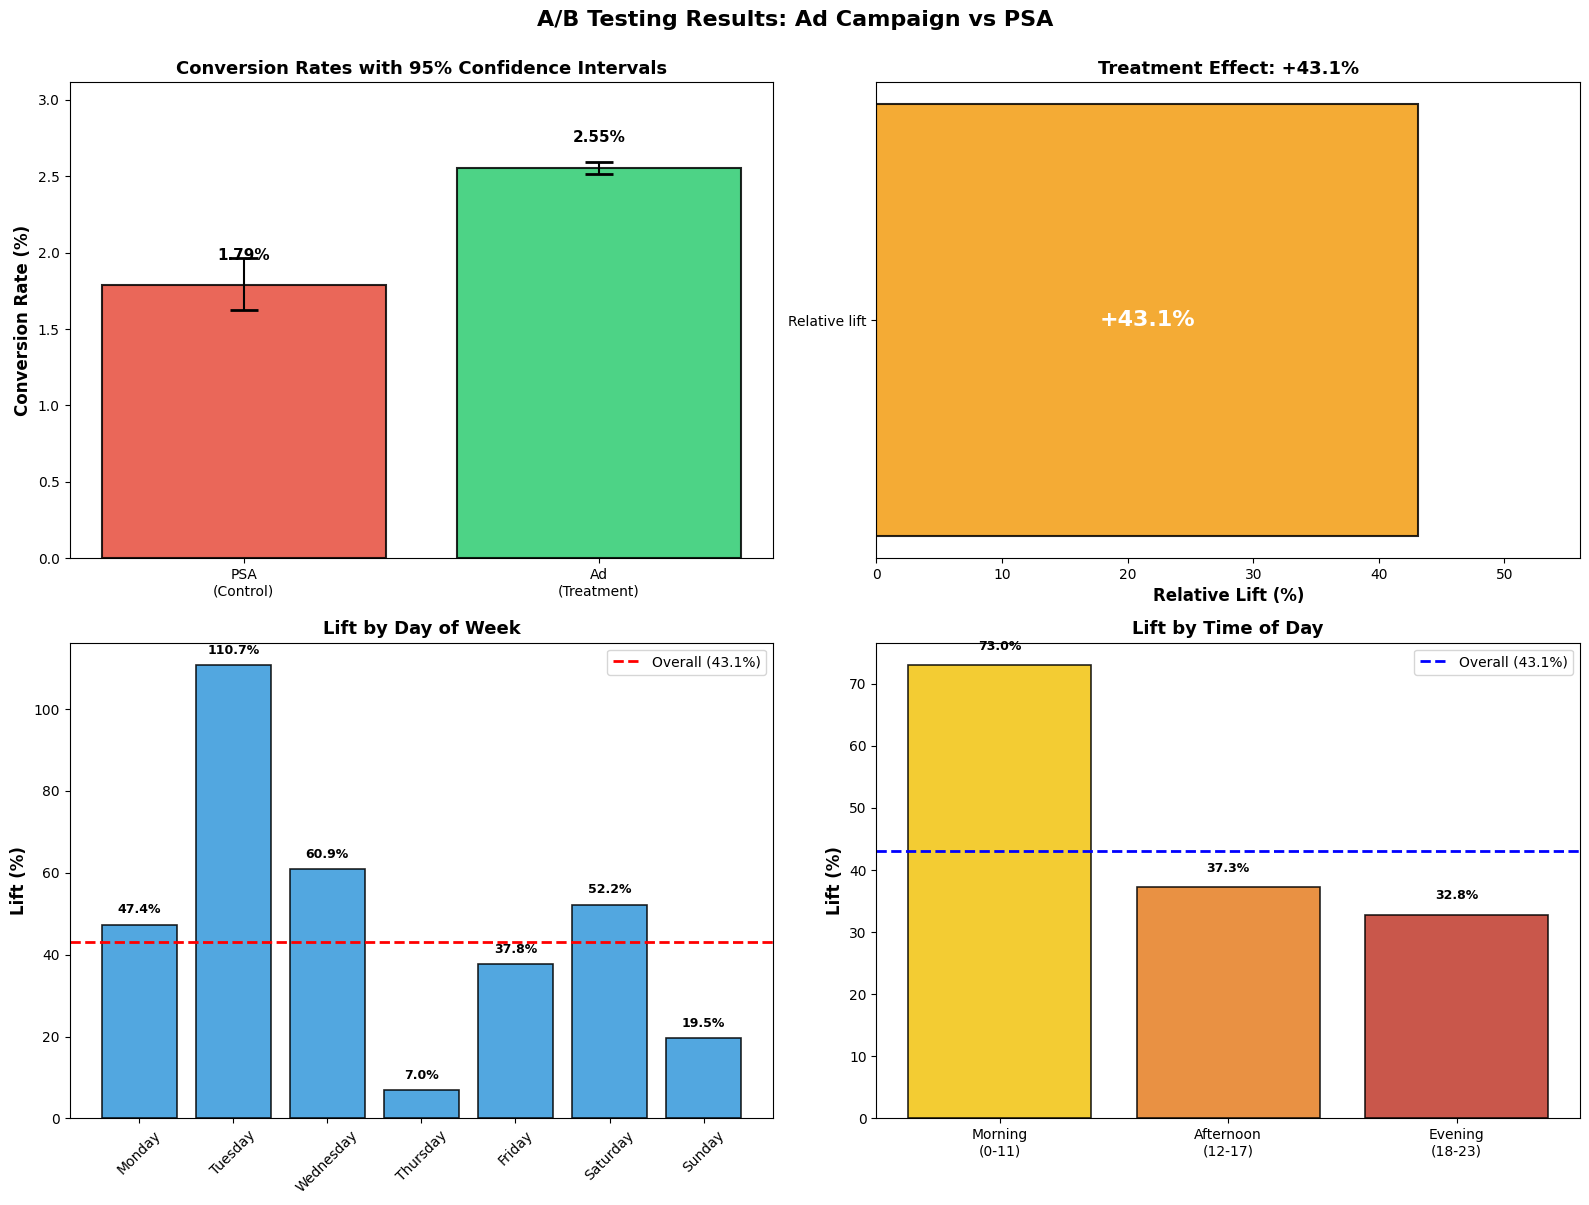

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
groups = ['PSA\n(Control)', 'Ad\n(Treatment)']
conversion_rates = [psa_conversion_rate * 100, ad_conversion_rate * 100]
ci_lower = [psa_ci[0] * 100, ad_ci[0] * 100]
ci_upper = [psa_ci[1] * 100, ad_ci[1] * 100]
errors = [
    [conversion_rates[0] - ci_lower[0], conversion_rates[1] - ci_lower[1]],
    [ci_upper[0] - conversion_rates[0], ci_upper[1] - conversion_rates[1]],
]
colors = ['#e74c3c', '#2ecc71']
bars = ax1.bar(groups, conversion_rates, color=colors, alpha=0.85, edgecolor='black', linewidth=1.5)
ax1.errorbar(groups, conversion_rates, yerr=errors, fmt='none', ecolor='black', capsize=10, capthick=2)
ax1.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Conversion Rates with 95% Confidence Intervals', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(ci_upper) * 1.2)
for bar, rate in zip(bars, conversion_rates):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15, f'{rate:.2f}%',
              ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2 = axes[0, 1]
ax2.barh(['Relative lift'], [relative_lift], color='#f39c12', alpha=0.85, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Relative Lift (%)', fontsize=12, fontweight='bold')
ax2.set_title(f'Treatment Effect: +{relative_lift:.1f}%', fontsize=13, fontweight='bold')
ax2.set_xlim(0, relative_lift * 1.3)
ax2.text(relative_lift / 2, 0, f'+{relative_lift:.1f}%', ha='center', va='center',
          fontsize=16, fontweight='bold', color='white')

ax3 = axes[1, 0]
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_lift_values = [lifts_by_day.get(d, 0) for d in days_order]
bars3 = ax3.bar(days_order, day_lift_values, color='#3498db', alpha=0.85, edgecolor='black', linewidth=1.2)
ax3.axhline(y=relative_lift, color='red', linestyle='--', linewidth=2, label=f'Overall ({relative_lift:.1f}%)')
ax3.set_ylabel('Lift (%)', fontsize=12, fontweight='bold')
ax3.set_title('Lift by Day of Week', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.tick_params(axis='x', rotation=45)
for bar, lift in zip(bars3, day_lift_values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, f'{lift:.1f}%',
              ha='center', va='bottom', fontsize=9, fontweight='bold')

ax4 = axes[1, 1]
time_periods = list(lifts_by_time.keys())
time_labels = [p.replace(' (', '\n(') for p in time_periods]
time_lift_values = [lifts_by_time[p] for p in time_periods]
bars4 = ax4.bar(time_labels, time_lift_values, color=['#f1c40f', '#e67e22', '#c0392b'],
                 alpha=0.85, edgecolor='black', linewidth=1.2)
ax4.axhline(y=relative_lift, color='blue', linestyle='--', linewidth=2, label=f'Overall ({relative_lift:.1f}%)')
ax4.set_ylabel('Lift (%)', fontsize=12, fontweight='bold')
ax4.set_title('Lift by Time of Day', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
for bar, lift in zip(bars4, time_lift_values):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, f'{lift:.1f}%',
              ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('A/B Testing Results: Ad Campaign vs PSA', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('ab_testing_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

## Final report

Written to `AB_TESTING_FINAL_REPORT.txt`. The recommendation is stated with the same
caveats as above (SRM check limitation, day&times;time interaction untested) rather than
as an unqualified conclusion.

In [12]:
report = f"""
A/B TESTING FINAL REPORT
Marketing Ad Campaign vs PSA (Public Service Announcement)
{'=' * 90}

EXECUTIVE SUMMARY
{'-' * 90}
CONTROL GROUP (PSA): {len(psa_group):,} users shown public service announcements
TREATMENT GROUP (Ad): {len(ad_group):,} users shown advertisements

                          Conversion Rate     95% CI                  Users
  PSA (Control):         {psa_conversion_rate*100:>6.2f}%          {psa_ci[0]*100:.2f}% - {psa_ci[1]*100:.2f}%          {len(psa_group):>10,}
  Ad (Treatment):        {ad_conversion_rate*100:>6.2f}%          {ad_ci[0]*100:.2f}% - {ad_ci[1]*100:.2f}%         {len(ad_group):>10,}
  {'-' * 86}
  Absolute lift:         {absolute_lift*100:>6.2f} percentage points
  Relative lift:         {relative_lift:>6.2f}%

STATISTICAL ANALYSIS
{'-' * 90}
Test: chi-squared test of independence (appropriate for a binary outcome)
  chi-squared statistic: {chi2:.4f}
  p-value: {p_value:.2e}

If there were no real difference between ads and PSAs, a difference this large would
occur by chance with probability {p_value:.2e} -- the difference is statistically
significant at the 0.05 level.

VALIDITY CHECKS
{'-' * 90}
1. Chi-squared assumptions: all expected frequencies >= 5 -- {(expected_freq >= 5).all()}
2. Simpson's paradox: lift stayed positive across every day-of-week and time-of-day
   subgroup checked ({no_reversal}), so the aggregate lift is not an artifact of pooling
   across a confound. This does not rule out an untested interaction (e.g. day x hour
   jointly).
3. Sample ratio mismatch: the observed 96:4 split is plausible as an intentional design
   choice, but the true intended allocation ratio isn't known, so this check is
   informative rather than conclusive.

SUBGROUP ANALYSIS: WHEN DO ADS WORK BEST?
{'-' * 90}
By day of week:
"""
for day in sorted(lifts_by_day, key=lifts_by_day.get, reverse=True):
    report += f"  {day:12s} {lifts_by_day[day]:+6.1f}% lift\n"

report += f"""
By time of day (excludes {excluded_hour0:,} users with hour==0, not covered by any bin):
"""
for period, lift in lifts_by_time.items():
    report += f"  {period:20s} {lift:+6.1f}% lift\n"

report += f"""
Note: combining the best day and best time lift figures by addition is not a measured
result -- the day x time interaction itself was never directly tested.

BUSINESS IMPACT
{'-' * 90}
Current (PSA only): {psa_conversion_rate*100:.2f}% conversion, {int(psa_conversion_rate*10000):,} per 10,000 users
Ad rollout:         {ad_conversion_rate*100:.2f}% conversion, {int(ad_conversion_rate*10000):,} per 10,000 users

Projected additional conversions at scale:
  100K users:   +{int(absolute_lift*100_000):,}
  1M users:     +{int(absolute_lift*1_000_000):,}
  10M users:    +{int(absolute_lift*10_000_000):,}

At $100 per conversion, 1M users: +${int(absolute_lift*1_000_000*100):,} revenue

RECOMMENDATION
{'-' * 90}
The evidence supports rolling out ads over PSAs: the lift is statistically significant,
holds consistently across every subgroup checked, and is large enough in absolute terms
to matter at scale. The two open caveats above (SRM test validity, untested day x time
interaction) don't change that conclusion, but are worth tracking with a follow-up test
if the platform's actual intended allocation ratio becomes available, or if a combined
day x time campaign is tried directly rather than inferred by addition.

Report generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Analyst: Chanindu Dahanayake
"""

print(report)

with open('AB_TESTING_FINAL_REPORT.txt', 'w') as f:
    f.write(report)


A/B TESTING FINAL REPORT
Marketing Ad Campaign vs PSA (Public Service Announcement)

EXECUTIVE SUMMARY
------------------------------------------------------------------------------------------
CONTROL GROUP (PSA): 23,524 users shown public service announcements
TREATMENT GROUP (Ad): 564,577 users shown advertisements

                          Conversion Rate     95% CI                  Users
  PSA (Control):           1.79%          1.62% - 1.96%              23,524
  Ad (Treatment):          2.55%          2.51% - 2.60%            564,577
  --------------------------------------------------------------------------------------
  Absolute lift:           0.77 percentage points
  Relative lift:          43.09%

STATISTICAL ANALYSIS
------------------------------------------------------------------------------------------
Test: chi-squared test of independence (appropriate for a binary outcome)
  chi-squared statistic: 54.0058
  p-value: 2.00e-13

If there were no real difference betwe